# Variable Importance

In this notebook we compare three methods of assessing the importance of input variables (abundance measurements on biomolecules) to some the predicted output (e.g. virus vs non-virus). The three methods are:

1. **SHAP** - SHapley Additive exPlanations
2. **Integrated Gradients** - Integrated Gradients
3. **ANOVA p-values**

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from models.multi_mlp import simple_FC, JointMLP

from featimportance.igrads import integrated_grads
from featimportance.comparison import overlap_sets
from featimportance.plot_helpers import igrad_beeswarm_plot, make_igrad_plot_df
import shap

import numpy as np
import pandas as pd
import copy
import datetime
from tqdm import tqdm_notebook as tqdm

from sklearn.metrics import roc_curve, auc, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

## Load ICL-104

In [3]:
proData = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_proteins_luke.csv')
lipData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/ICL104_lipids_aligned_for_stats.xlsx")
metabData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/OMICS_ICL104_Metabolomics_YMK.xlsx")
metabData = metabData.drop(columns=['KEGG', 'CAS', 'PubChem'])

fmeta = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_fmeta.csv')

In [4]:
# some samples missing from some datasets.
lipData.shape, metabData.shape, proData.shape

((250, 61), (138, 61), (2853, 61))

In [5]:
# filter all rows in fmeta where any of SampleID_proteomics, SampleID_proteomics, SampleID_metab are NA
fmeta = fmeta[~fmeta[['SampleID_proteomics', 'SampleID_lipidpos', 'SampleID_metab']].isna().any(axis=1)]
fmeta['Virus_y'] = fmeta.Virus.replace({'Cal[0-9]*': 'Cal'}, regex=True)
y = fmeta.Virus_y

In [6]:
# make the "LIPID" column in lipData the index
lipData = lipData.set_index('Name')
metabData = metabData.set_index('Metabolite')
proData = proData.set_index('Protein')

# replace zeros with NA
lipData[lipData == 0] = np.nan
metabData[metabData == 0] = np.nan

# log2 transform the data and column-wise median center
lipData = np.log2(lipData)
metabData = np.log2(metabData)
# proData = np.log2(proData) # don't if already log2

lipData = lipData - lipData.median(axis=0)
metabData = metabData - metabData.median(axis=0)
proData = proData - proData.median(axis=0)

# [0, 1] normalize all the data
lipData = (lipData - np.min(lipData)) / (np.max(lipData) - np.min(lipData))
metabData = (metabData - np.min(metabData)) / (np.max(metabData) - np.min(metabData))
proData = (proData - np.min(proData)) / (np.max(proData) - np.min(proData))

In [7]:
# columns are nicely aligned
y = pd.Series(['Cal' if 'Cal04' in el else 'Mock' for el in lipData.columns])

In [8]:
# drop indices with all null values
lip_inds = (lipData.isnull() == False).sum(axis = 1) > 0
metab_inds = (metabData.isnull() == False).sum(axis = 1) > 0
pro_inds = (proData.isnull() == False).sum(axis = 1) > 0

lipData = lipData[lip_inds]
metabData = metabData[metab_inds]
proData = proData[pro_inds]

# impute the datasets with the row means
lipData = lipData.apply(lambda row: row.fillna(row.mean()), axis=1)
metabData = metabData.apply(lambda row: row.fillna(row.mean()), axis=1)
proData = proData.apply(lambda row: row.fillna(row.mean()), axis=1)


In [9]:
# Use this if our column names are aligned with f_meta, otherwise make sure to manually check that they align
# lipData = lipData.loc[:,lipData.columns.isin(fmeta['SampleID_lipidpos'])]
# metabData = metabData.loc[:,metabData.columns.isin(fmeta['SampleID_metab'])]
# proData = proData.loc[:,proData.columns.isin(fmeta['SampleID_proteomics'])]

In [10]:
np.random.seed(1565)
cal_inds = np.random.choice(np.where(y == 'Cal')[0], int(np.sum(y == 'Cal') * 0.2))
mock_inds = np.random.choice(np.where(y == 'Mock')[0], int(np.sum(y == 'Mock') * 0.2))
test_inds = np.concatenate([cal_inds, mock_inds])

train_inds = np.isin(np.arange(y.shape[0]), test_inds) == False

train_lip = lipData.iloc[:,train_inds]
train_pro = proData.iloc[:,train_inds]
train_metab = metabData.iloc[:,train_inds]

test_lip = lipData.iloc[:, test_inds]
test_pro = proData.iloc[:, test_inds]
test_metab = metabData.iloc[:, test_inds]

ytrain = y.iloc[train_inds]
ytest = y.iloc[test_inds]

### Construct and Train the Model

In [11]:
# three view-specific encoders with the appropriate input size:

# the last hidden size must be the same since we are averaging
last_hidden_size = 64

lip_marg = simple_FC(input_size=train_lip.shape[0], hidden_sizes=[128, last_hidden_size], prediction_dim=y.nunique())
metab_marg = simple_FC(input_size=train_metab.shape[0], hidden_sizes=[64, last_hidden_size], prediction_dim=y.nunique())
pro_marg = simple_FC(input_size=train_pro.shape[0], hidden_sizes=[256, last_hidden_size], prediction_dim=y.nunique())

# joint model
joint_model = JointMLP(marginal_models=[lip_marg, metab_marg, pro_marg], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-4)

In [12]:
# turn data into tensors
lip_tensor = torch.tensor(train_lip.T.values, dtype=torch.float32)
pro_tensor = torch.tensor(train_pro.T.values, dtype=torch.float32)
metab_tensor = torch.tensor(train_metab.T.values, dtype=torch.float32)

y_gt = ytrain.astype('category').cat.codes
y_gt = torch.tensor(y_gt.values, dtype=torch.int64)

for i in range(1250):

    views = [lip_tensor, metab_tensor, pro_tensor]
    
    # randomly drop an index with low probability
    if np.random.rand() < 0.1:
        idx = np.random.randint(0, len(views))
        views = [v if i != idx else None for i, v in enumerate(views)]

    # get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
    yhat, h, yhats, hiddens = joint_model(views)

    # pass the predictions and distributions to the loss function and update parameters
    loss = joint_model.loss(y_gt, yhat, yhats)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
    optimizer.step()

    print(f'Epoch {i+1} loss: {loss.item():.3f}')

Epoch 1 loss: 0.710
Epoch 2 loss: 0.710
Epoch 3 loss: 0.690
Epoch 4 loss: 0.699
Epoch 5 loss: 0.694
Epoch 6 loss: 0.705
Epoch 7 loss: 0.700
Epoch 8 loss: 0.697
Epoch 9 loss: 0.693
Epoch 10 loss: 0.697
Epoch 11 loss: 0.701
Epoch 12 loss: 0.701
Epoch 13 loss: 0.690
Epoch 14 loss: 0.705
Epoch 15 loss: 0.686
Epoch 16 loss: 0.693
Epoch 17 loss: 0.517
Epoch 18 loss: 0.697
Epoch 19 loss: 0.700
Epoch 20 loss: 0.697
Epoch 21 loss: 0.688
Epoch 22 loss: 0.697
Epoch 23 loss: 0.520
Epoch 24 loss: 0.697
Epoch 25 loss: 0.691
Epoch 26 loss: 0.691
Epoch 27 loss: 0.521
Epoch 28 loss: 0.694
Epoch 29 loss: 0.698
Epoch 30 loss: 0.689
Epoch 31 loss: 0.692
Epoch 32 loss: 0.697
Epoch 33 loss: 0.692
Epoch 34 loss: 0.687
Epoch 35 loss: 0.693
Epoch 36 loss: 0.695
Epoch 37 loss: 0.692
Epoch 38 loss: 0.693
Epoch 39 loss: 0.700
Epoch 40 loss: 0.698
Epoch 41 loss: 0.693
Epoch 42 loss: 0.689
Epoch 43 loss: 0.694
Epoch 44 loss: 0.693
Epoch 45 loss: 0.691
Epoch 46 loss: 0.684
Epoch 47 loss: 0.692
Epoch 48 loss: 0.696
E

In [13]:
# example prediction
joint_model.eval()

ytest_gt = ytest.astype('category').cat.codes

liptest_tensor = torch.tensor(test_lip.T.values, dtype=torch.float32)
protest_tensor = torch.tensor(test_pro.T.values, dtype=torch.float32)
metabtest_tensor = torch.tensor(test_metab.T.values, dtype=torch.float32)

with torch.inference_mode():
    yhat, hiddens, yhats, dists = joint_model([liptest_tensor, metabtest_tensor, protest_tensor])

ypred = yhat.argmax(dim=1).numpy()

(ypred == ytest_gt.to_numpy()).mean()

1.0

# Basic Gradient * Input

The first example is just for demonstration of the concept that underlies some methods, which is to use the gradients of the input with respect to the output. This is a simple method that is not very robust, but it is the basis for some more advanced methods.  The method simply passes in examples, computes gradients of the inputs with respect to the predicted probability of e.g. the positive class, and then multiplies those gradients by the raw input values.

In [104]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 0])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 0])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 0])

liptest_pos.requires_grad = True
protest_pos.requires_grad = True
metabtest_pos.requires_grad = True

yhat, h, yhats, hiddens = joint_model([liptest_pos, metabtest_pos, protest_pos])

yhat[:,1].mean().backward()

In [105]:
liptest_scores = liptest_pos.grad * liptest_pos
protest_scores = protest_pos.grad * protest_pos
metabtest_scores = metabtest_pos.grad * metabtest_pos

(
liptest_scores.sum(axis = 0).argsort()[:10],
protest_scores.sum(axis = 0).argsort()[:10],
metabtest_scores.sum(axis = 0).argsort()[:10]
)

(tensor([  3, 236, 243,  95, 204,  53, 201,  35, 244, 205]),
 tensor([1548, 1532, 2446,  604, 2690, 1109,  901, 2369,   74, 2815]),
 tensor([ 51, 109, 100, 124, 130,  57,  65, 113,  17, 108]))

### Shapley Values

Shapley values are a method of assigning importance to input variables.  The particular flavor of the Shapley values framework is a version of DEEPLift (Shrikumar, Greenside, and Kundaj, 2017), implemented in the SHAP packages (https://shap.readthedocs.io/en/latest/index.html) and modified with findings from (Lee and Lundberg, 2017).

In [14]:
# need to wrap the model in this class to get around some issues with the SHAP package
class JointMLPWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x1, x2, x3):
        yhat, _, _, _ = self.model([x1, x2, x3])
        return yhat
    
joint_model_wrp = JointMLPWrapper(joint_model)

In [15]:
# make the explainer object
explainer = shap.DeepExplainer(joint_model_wrp, views)

In [16]:
# compute the shapley values
shap_values = explainer.shap_values([liptest_tensor, metabtest_tensor, protest_tensor], check_additivity=False)

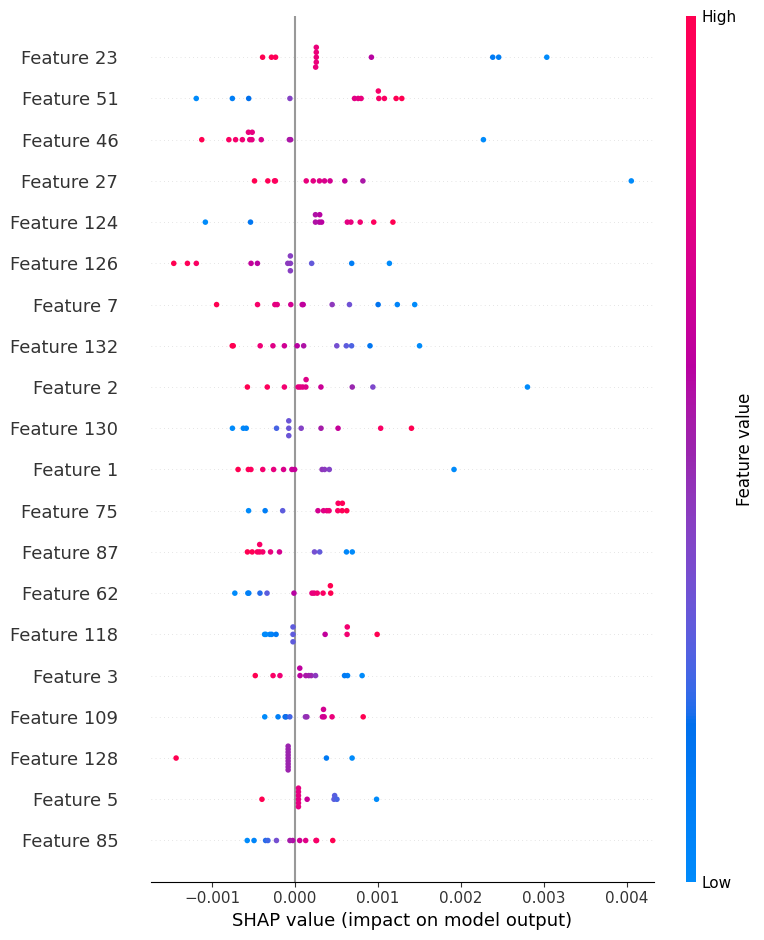

In [18]:
# index 0 is for the positive class
shap_lip = shap_values[0][0]
shap_metab = shap_values[0][1]
shap_pro = shap_values[0][2]

shap.summary_plot(shap_metab, metabtest_tensor)

In [19]:
# absolute sum values and sorted scores
abs_lip_shap = np.abs(shap_lip).sum(axis = 0)
abs_pro_shap = np.abs(shap_pro).sum(axis = 0)
abs_metab_shap = np.abs(shap_metab).sum(axis = 0)

sorted_lip_shap = sorted(abs_lip_shap, reverse = True)
sorted_pro_shap = sorted(abs_pro_shap, reverse = True)
sorted_metab_shap = sorted(abs_metab_shap, reverse = True)

# shap output dataframes
lipids_shap = pd.DataFrame({
    "Lipids":test_lip.iloc[(-abs_lip_shap).argsort(), :].index,
    "Lipid_Scores": sorted_lip_shap
})

proteins_shap = pd.DataFrame({
    "Proteins": test_pro.iloc[(-abs_pro_shap).argsort(), :].index,
    "Protein_Scores": sorted_pro_shap
})

metabolites_shap = pd.DataFrame({
    "Metabolites": test_metab.iloc[(-abs_metab_shap).argsort(), :].index,
    "Metabolite_Scores": sorted_metab_shap
})

lip_shap_scores_df = pd.DataFrame(shap_lip.T)
lip_shap_scores_df.index = test_lip.index
lip_shap_scores_df.columns = test_lip.columns

pro_shap_scores_df = pd.DataFrame(shap_pro.T)
pro_shap_scores_df.index = test_pro.index
pro_shap_scores_df.columns = test_pro.columns

metab_shap_scores_df = pd.DataFrame(shap_metab.T)
metab_shap_scores_df.index = test_metab.index
metab_shap_scores_df.columns = test_metab.columns

lipids_shap_out = lipids_shap.merge(lip_shap_scores_df, how = 'left', left_on = 'Lipids', right_on = "Name")
proteins_shap_out = proteins_shap.merge(pro_shap_scores_df, how = 'left', left_on = 'Proteins', right_on = "Protein")
metabolites_shap_out = metabolites_shap.merge(metab_shap_scores_df, how = 'left', left_on = 'Metabolites', right_on = "Metabolite")

In [ ]:
# check we aligned columns correctly
assert((lipids_shap_out.iloc[:, 2:].abs().sum(axis=1) == lipids_shap_out.Lipid_Scores).all())
assert((proteins_shap_out.iloc[:, 2:].abs().sum(axis=1) == proteins_shap_out.Protein_Scores).all())
assert((metabolites_shap_out.iloc[:, 2:].abs().sum(axis=1) == metabolites_shap_out.Metabolite_Scores).all())

In [ ]:
lipids_shap_out.to_csv(f"./output/lipids_shap_mlp_{thetime}.csv")
proteins_shap_out.to_csv(f"./output/proteins_shap_mlp_{thetime}.csv")
metabolites_shap_out.to_csv(f"./output/metabolites_shap_mlp_{thetime}.csv")

# Integrated Gradients

Integrated gradients overcome the problem of non-sensitivity of gradients methods, see https://arxiv.org/pdf/1703.01365.pdf for an explanation.  

As described in the paper, we start at some 'non-informative' baseline, and move linearly towards our actual input, taking the gradient at each step and accumulating.  At the end we divide by the number of steps to get the average gradient, which approximates an integral.  This is the integrated gradient and the magnitude of each score can be seen as the strength of attribute, with the sign denoting the effect of the variable on the outcome.

We'll compare these to SHAP values, which are a more general approach to the same problem.

In [21]:
thetime = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 0])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 0])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 0])

In [22]:
# baseline is normal noise with mean and std from the data
# vary these to see if we get different results...
# scree plot
# lip_baseline = torch.randn_like(liptest_pos)*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
# pro_baseline = torch.randn_like(protest_pos)*protest_pos.std().numpy() + protest_pos.mean().numpy()
# metab_baseline = torch.randn_like(metabtest_pos)*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

lip_baseline = -torch.rand_like(liptest_pos)/2# *2*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
pro_baseline = -torch.rand_like(protest_pos)/2# *2*protest_pos.std().numpy() + protest_pos.mean().numpy()
metab_baseline = -torch.rand_like(metabtest_pos)/2# *2*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

# shuffle values of lip_baseline
lip_baseline = lip_baseline[:,torch.randperm(lip_baseline.shape[1])]
pro_baseline = pro_baseline[:,torch.randperm(pro_baseline.shape[1])]
metab_baseline = metab_baseline[:,torch.randperm(metab_baseline.shape[1])]


In [27]:
joint_model.eval()

lip_igrad_scores, metab_igrad_scores, pro_igrad_scores = integrated_grads(
    [liptest_pos, metabtest_pos, protest_pos], 
    [lip_baseline, metab_baseline, pro_baseline], 
    joint_model, n_steps = 100, class_idx = 0 # regrettably, 0 represents the 'Virus' condition here, no I'm not going to fix it.
)

In [28]:
top_lip = (-lip_igrad_scores.abs().sum(axis = 0)).argsort()[:10]
top_pro = (-pro_igrad_scores.abs().sum(axis = 0)).argsort()[:10]
top_metab = (-metab_igrad_scores.abs().sum(axis = 0)).argsort()[:10]

(
test_lip.iloc[top_lip.numpy(), :].index,
test_pro.iloc[top_pro.numpy(), :].index,
test_metab.iloc[top_metab.numpy(), :].index
)

(Index(['Cer(d18:0/24:0)', 'TG(51:1)', 'TG(54:4)', 'DG(18:1/18:2/0:0)',
        'Cer(d18:0/26:0);Cer(d20:0/24:0)', 'TG(8:0/16:1/18:1)',
        'PC(18:2/0:0)_B', 'Cer(d18:0/24:1)', 'PC(16:1/0:0)_A',
        'DG(18:1/20:1/0:0)'],
       dtype='object', name='Name'),
 Index(['H1N1_CA04_NP', 'H1N1_CA04_NS1', 'H1N1_CA04_M1', 'TSP2_HUMAN',
        'TSP1_HUMAN', 'SYCC_HUMAN', 'BGH3_HUMAN', 'SPIT2_HUMAN', 'ITB4_HUMAN',
        'DOCK7_HUMAN'],
       dtype='object', name='Protein'),
 Index(['L-methionine', '3-phosphoglyceric acid', '3-hydroxybutyric acid',
        'Unknown 066', 'L-threonic acid*', 'pyruvic acid', 'glyceric acid',
        'Unknown 056', 'Unknown 062', 'Unknown 029'],
       dtype='object', name='Metabolite'))

In [30]:
abs_lip_igrads = lip_igrad_scores.abs().sum(axis = 0).numpy()
abs_pro_igrads = pro_igrad_scores.abs().sum(axis = 0).numpy()
abs_metab_igrads = metab_igrad_scores.abs().sum(axis = 0).numpy()

sorted_lip_igrads = sorted(abs_lip_igrads, reverse = True)
sorted_pro_igrads = sorted(abs_pro_igrads, reverse = True)
sorted_metab_igrads = sorted(abs_metab_igrads, reverse = True)

In [31]:
# Output dataframes
lipids_igrad = pd.DataFrame({
    "Lipids":test_lip.iloc[(-abs_lip_igrads).argsort(), :].index,
    "Lipid_Scores": sorted_lip_igrads
})

proteins_igrad = pd.DataFrame({
    "Proteins": test_pro.iloc[(-abs_pro_igrads).argsort(), :].index,
    "Protein_Scores": sorted_pro_igrads
})

metabolites_igrad = pd.DataFrame({
    "Metabolites": test_metab.iloc[(-abs_metab_igrads).argsort(), :].index,
    "Metabolite_Scores": sorted_metab_igrads
})

lip_igrad_scores_df = pd.DataFrame(lip_igrad_scores.T)
lip_igrad_scores_df.index = test_lip.index
lip_igrad_scores_df.columns = test_lip.columns[ytest_gt.to_numpy() == 0]

pro_igrad_scores_df = pd.DataFrame(pro_igrad_scores.T)
pro_igrad_scores_df.index = test_pro.index
pro_igrad_scores_df.columns = test_pro.columns[ytest_gt.to_numpy() == 0]

metab_igrad_scores_df = pd.DataFrame(metab_igrad_scores.T)
metab_igrad_scores_df.index = test_metab.index
metab_igrad_scores_df.columns = test_metab.columns[ytest_gt.to_numpy() == 0]

# left join lipids_out to lip int scores "Lipids" = "Name"
lipids_igrad_out = lipids_igrad.merge(lip_igrad_scores_df, how = 'left', left_on = 'Lipids', right_on = "Name")
# left join proteins_out to pro int scores "Proteins" = "Protein"
proteins_igrad_out = proteins_igrad.merge(pro_igrad_scores_df, how = 'left', left_on = 'Proteins', right_on = "Protein")
# left join metabolites_out to metab int scores "Metabolites" = "Metabolite"
metabolites_igrad_out = metabolites_igrad.merge(metab_igrad_scores_df, how = 'left', left_on = 'Metabolites', right_on = "Metabolite")

### Integrated Gradient Plots

We plot the same beeswarm plots for integrated gradients as we did for SHAP values.  First we have to make some long dataframes that can be passed to seaborn:

In [32]:
lip_igrad_plot_df = make_igrad_plot_df(lipids_igrad_out, test_lip.reset_index(), num_biomols = 10, id_vars = "Name", var_name = "SampleID", value_name = "Input_value")
pro_igrad_plot_df = make_igrad_plot_df(proteins_igrad_out, test_pro.reset_index(), num_biomols = 10, id_vars = "Protein", var_name = "SampleID", value_name = "Input_value")
metab_igrad_plot_df = make_igrad_plot_df(metabolites_igrad_out, test_metab.reset_index(), num_biomols = 10, id_vars = "Metabolite", var_name = "SampleID", value_name = "Input_value")



The palette list has fewer values (5) than needed (59) and will cycle, which may produce an uninterpretable plot.


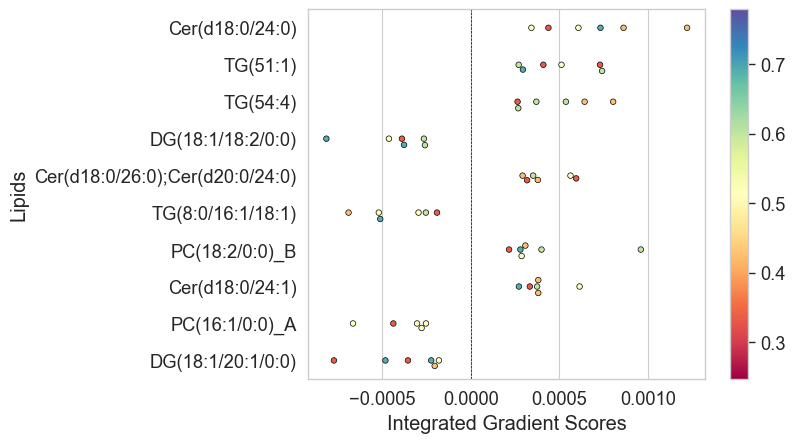

In [90]:
igrad_beeswarm_plot(lip_igrad_plot_df, ycol = "Lipids", ylabel = "Lipids")


The palette list has fewer values (5) than needed (59) and will cycle, which may produce an uninterpretable plot.


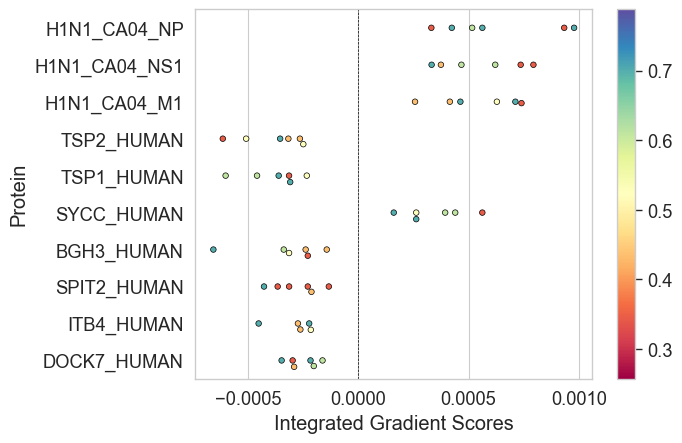

In [37]:
igrad_beeswarm_plot(pro_igrad_plot_df, ycol = "Protein", ylabel = "Protein")

### Testing the stability of integrated gradients across random baselines

Integrated gradients are sensitive to the choice of baseline.  We can test the stability of the integrated gradients by running the same analysis with different random baselines.

In [98]:
lip_ranks = {}
pro_ranks = {}
metab_ranks = {}

for k in range(50):
    lip_baseline = -torch.rand_like(liptest_pos)/2# *2*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
    pro_baseline = -torch.rand_like(protest_pos)/2# *2*protest_pos.std().numpy() + protest_pos.mean().numpy()
    metab_baseline = -torch.rand_like(metabtest_pos)/2# *2*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

    lip_int_scores, metab_int_scores, pro_int_scores = integrated_grads(
        [liptest_pos, metabtest_pos, protest_pos], 
        [lip_baseline, metab_baseline, pro_baseline], 
        joint_model, n_steps = 100, class_idx = 1
    )

    lip_argsort = (-lip_int_scores.abs().sum(axis = 0)).argsort()
    pro_argsort = (-pro_int_scores.abs().sum(axis = 0)).argsort()
    metab_argsort = (-metab_int_scores.abs().sum(axis = 0)).argsort()

    for r, i in enumerate(lip_argsort.numpy()):
        lip_ranks.setdefault(i, []).append(r)
    
    for r, i in enumerate(pro_argsort.numpy()):
        pro_ranks.setdefault(i, []).append(r)

    for r, i in enumerate(metab_argsort.numpy()):
        metab_ranks.setdefault(i, []).append(r)

In [99]:
lip_mu_std = {k: (np.mean(v), np.std(v)) for k, v in lip_ranks.items()}
pro_mu_std = {k: (np.mean(v), np.std(v)) for k, v in pro_ranks.items()}
metab_mu_std = {k: (np.mean(v), np.std(v)) for k, v in metab_ranks.items()}

In [102]:
# lipids sorted by their mean rank.  Lipids with lower mean rank are more 
# important and we look for ones which also have low standard deviation in their rank across the 50 runs.
sorted(lip_mu_std.items(), key = lambda x: x[1][0], reverse = False)[:10]

[(3, (0.0, 0.0)),
 (236, (1.56, 1.134195750300626)),
 (243, (3.24, 1.9550959055759898)),
 (101, (4.96, 3.411509929635263)),
 (38, (5.34, 3.8709688709675776)),
 (204, (8.6, 4.569463863518345)),
 (223, (8.78, 5.470977974731757)),
 (73, (9.98, 6.718601044860455)),
 (53, (10.82, 7.393754120877973)),
 (201, (12.2, 4.209513035969837))]

In [441]:
# check that we aligned the columns correctly
assert(np.isclose(lipids_igrad_out.iloc[:, 2:].abs().sum(axis=1), lipids_igrad_out.Lipid_Scores).all())
assert(np.isclose(proteins_igrad_out.iloc[:, 2:].abs().sum(axis=1), proteins_igrad_out.Protein_Scores).all())
assert(np.isclose(metabolites_igrad_out.iloc[:, 2:].abs().sum(axis=1), metabolites_igrad_out.Metabolite_Scores).all())

In [206]:
# Write out dataframes
thetime = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

lipids_igrad_out.to_csv(f"./output/lipids_igrads_mlp_{thetime}.csv")
proteins_igrad_out.to_csv(f"./output/proteins_igrads_mlp_{thetime}.csv")
metabolites_igrad_out.to_csv(f"./output/metabolites_igrads_mlp_{thetime}.csv")


## Compare both to each other and ANOVA results

We compare the integrated gradient and shapley value results to the ANOVA via a hypergeometric distribution.  Essentially, we want to know, if we select the top $n_1$ biomolecules from integrated gradients, what is the probability that we would observe the amount of overlap with the top $n_2$ biomolecules from ANOVA by chance?  We can calculate this probability using the hypergeometric distribution.

The choice of $n_1$ and $n_2$ is a but subjective, however 10% of all biomolecules seems reasonable.

In [91]:
# significant biomolecules
pro_anova = pd.read_csv("./data/anova_results/pep/anova_results.csv")
lip_pos_anova = pd.read_csv("./data/anova_results/lip_pos/anova_results.csv")
metab_anova = pd.read_csv("./data/anova_results/metab/anova_results.csv")

# sort pro_anova by p-value columns
top_pro_anova = pro_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)
top_lip_anova = lip_pos_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)
top_metab_anova = metab_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)

We take a look at some scree plots to see if there is a good cutoff for the number of biomolecules to include in the analysis.

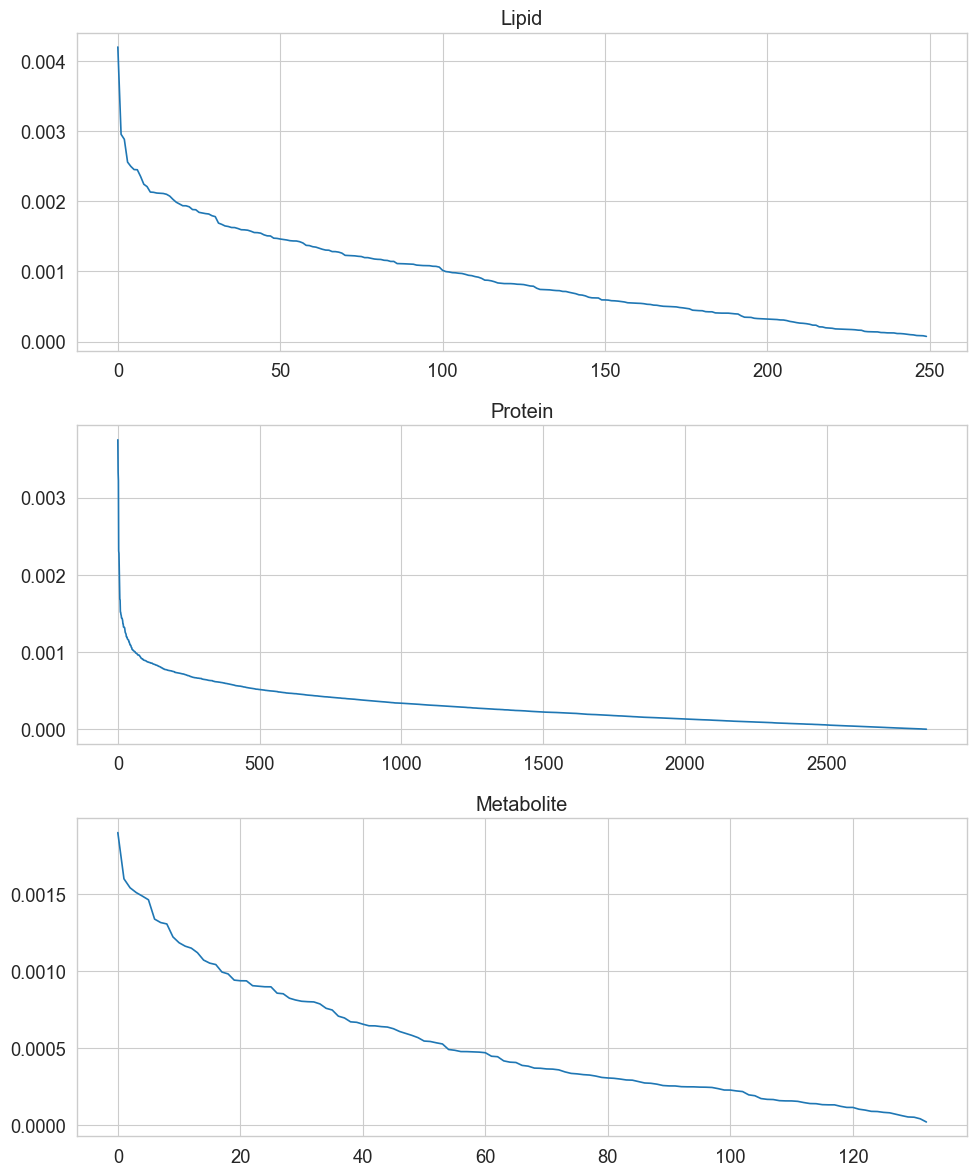

In [74]:
# integrated gradients
fig, axs = plt.subplots(3, 1, figsize = (10, 12))
axs[0].plot(sorted(abs_lip_igrads, reverse = True))
axs[1].plot(sorted(abs_pro_igrads, reverse = True))
axs[2].plot(sorted(abs_metab_igrads, reverse = True))

axs[0].set_title('Lipid')
axs[1].set_title('Protein')
axs[2].set_title('Metabolite')

plt.tight_layout()

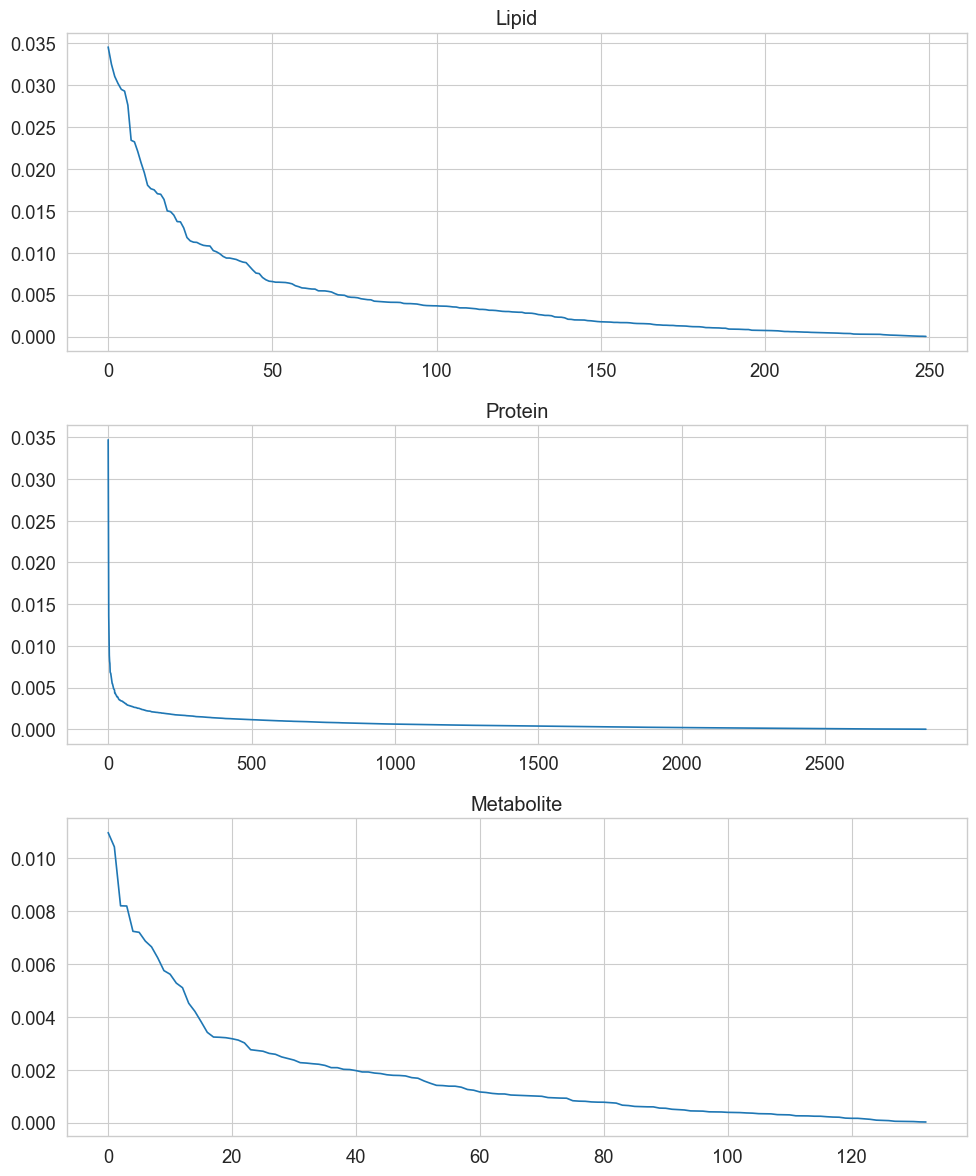

In [81]:
# shapley values
fig, axs = plt.subplots(3, 1, figsize = (10, 12))
axs[0].plot(sorted(abs_lip_shap, reverse = True))
axs[1].plot(sorted(abs_pro_shap, reverse = True))
axs[2].plot(sorted(abs_metab_shap, reverse = True))

axs[0].set_title('Lipid')
axs[1].set_title('Protein')
axs[2].set_title('Metabolite')

plt.tight_layout()

In [78]:
lip_igrad_quantiles = np.quantile(np.array(lipids_igrad['Lipid_Scores']), q = [.7, .8, .9])
pro_igrad_quantiles = np.quantile(np.array(proteins_igrad['Protein_Scores']), q = [.7, .8, .9])
metab_igrad_quantiles = np.quantile(np.array(metabolites_igrad['Metabolite_Scores']), q = [.7, .8, .9])

lip_shap_quantiles = np.quantile(np.array(lipids_shap['Lipid_Scores']), q = [.7, .8, .9])
pro_shap_quantiles = np.quantile(np.array(proteins_shap['Protein_Scores']), q = [.7, .8, .9])
metab_shap_quantiles = np.quantile(np.array(metabolites_shap['Metabolite_Scores']), q = [.7, .8, .9])


In [103]:
# proteins igrad vs SHAP
set1 = set(proteins_igrad[proteins_igrad["Protein_Scores"] > 0.001]['Proteins'])
set2 = set(proteins_shap[proteins_shap["Protein_Scores"] > 0.004]['Proteins'])
set3 = set(top_pro_anova[top_pro_anova['P_value_A_Cal04_vs_Mock'] < 0.05]["Protein"])

_ = overlap_sets(set1, set2, M = proteins_shap.shape[0])
_ = overlap_sets(set3, set2, M = proteins_shap.shape[0])
_ = overlap_sets(set3, set1, M = proteins_shap.shape[0])

p(x) : 1.0507239391940302e-34
p-value <= 23: 1.0
p-value >= 23: 1.0550295800682773e-34
p(x) : 9.374433614608803e-10
p-value <= 19: 0.9999999999086493
p-value >= 19: 1.028794118103227e-09
p(x) : 1.858692615466901e-25
p-value <= 45: 1.0
p-value >= 45: 1.9697026831668004e-25


In [95]:
# metabolites igrad vs SHAP
set1 = set(metabolites_igrad[metabolites_igrad["Metabolite_Scores"] > 0.001]['Metabolites'])
set2 = set(metabolites_shap[metabolites_shap["Metabolite_Scores"] > 0.004]['Metabolites'])
set3 = set(top_metab_anova[top_metab_anova['P_value_A_Cal04_vs_Mock'] < 0.05]["Metabolite"])

overlap_sets(set1, set2, M = metabolites_shap.shape[0])
overlap_sets(set3, set2, M = metabolites_shap.shape[0])
overlap_sets(set3, set1, M = metabolites_shap.shape[0])

p(x) : 1.284772031512193e-07
p-value <= 10: 0.999999996284822
p-value >= 10: 1.321923811632789e-07
p(x) : 0.02853156291529135
p-value <= 6: 0.9916109384593191
p-value >= 6: 0.036920624455972266
p(x) : 2.2614975212469883e-08
p-value <= 13: 0.9999999992460457
p-value >= 13: 2.3368929588483667e-08


(2.2614975212469883e-08, 0.9999999992460457, 2.3368929588483667e-08)

In [97]:
# lipids igrad vs SHAP
set1 = set(lipids_igrad[lipids_igrad["Lipid_Scores"] > 0.002]['Lipids'])
set2 = set(lipids_shap[lipids_shap["Lipid_Scores"] > 0.01]['Lipids'])
set3 = set(top_lip_anova[top_lip_anova['P_value_A_Cal04_vs_Mock'] < 0.05]["Lipid"])

_ = overlap_sets(set1, set2, M = lipids_shap.shape[0])
_ = overlap_sets(set3, set2, M = lipids_shap.shape[0]) # anova doesn't overlap with SHAP values for lipids
_ = overlap_sets(set3, set1, M = lipids_shap.shape[0])

p(x) : 5.93840339970229e-08
p-value <= 12: 0.9999999970386201
p-value >= 12: 6.234541391428732e-08
p(x) : 0.07903488675532462
p-value <= 13: 0.17332329202302768
p-value >= 13: 0.9057115947322969
p(x) : 0.017719216484513738
p-value <= 13: 0.9935111586660623
p-value >= 13: 0.024208057818451412


(0.017719216484513738, 0.9935111586660623, 0.024208057818451412)